# LLM Syscall Log — Exploratory Data Analysis
Data source: `aios/logs/llm_syscalls.jsonl`

**Features:** `syscall_id`, `agent_name`, `timestamp`, `input_char_length`, `message_count`, `has_tools`, `max_tokens`, `temperature`, `created_time`, `start_time`, `end_time`, `latency_ms`, `wait_ms`, `was_interrupted`, `error`

In [14]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from pathlib import Path
import re, os

sns.set_theme(style='whitegrid')

# ── Resolve path relative to this notebook ──────────────────────
NOTEBOOK_DIR = Path(os.getcwd())
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / 'aios').is_dir() else NOTEBOOK_DIR.parent
LOG_PATH = PROJECT_ROOT / 'aios' / 'logs' / 'llm_syscalls.jsonl'
print(f'Log file: {LOG_PATH}  (exists={LOG_PATH.exists()})')

rows = [json.loads(l) for l in open(LOG_PATH) if l.strip()]
df = pd.DataFrame(rows)

# ── Derive agent_type from agent_name (strip _rN suffix) ────────
df['agent_type'] = df['agent_name'].str.replace(r'_r\d+$', '', regex=True)
df['round'] = df['agent_name'].str.extract(r'_r(\d+)$').astype(int)
df['has_tools'] = df['has_tools'].astype(bool)

# ── Human-readable timestamp ────────────────────────────────────
df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')

print(f'Shape: {df.shape}')
print(f'\nDtypes:\n{df.dtypes}')
print(f'\nNull counts:\n{df.isnull().sum()}')
print(f'\nAgent types: {df["agent_type"].unique().tolist()}')
print(f'Rounds:      {sorted(df["round"].unique())}')
df.head()

Log file: /Users/muaazshaikh/AIOS-Cognitive/aios/logs/llm_syscalls.jsonl  (exists=True)
Shape: (500, 18)

Dtypes:
syscall_id                   object
agent_name                   object
timestamp                   float64
input_char_length             int64
message_count                 int64
has_tools                      bool
max_tokens                    int64
temperature                 float64
created_time                float64
start_time                  float64
end_time                    float64
latency_ms                  float64
wait_ms                     float64
was_interrupted                bool
error                          bool
agent_type                   object
round                         int64
datetime             datetime64[ns]
dtype: object

Null counts:
syscall_id           0
agent_name           0
timestamp            0
input_char_length    0
message_count        0
has_tools            0
max_tokens           0
temperature          0
created_time         0
sta

,syscall_id,agent_name,timestamp,input_char_length,message_count,has_tools,max_tokens,temperature,created_time,start_time,end_time,latency_ms,wait_ms,was_interrupted,error,agent_type,round,datetime
0,cf2ddfa4-7873-4cb5-bf04-8f9a9c0b18a2,short_qa_agent_r1,1.774533e+09,181,2,False,100,0.3,1.774533e+09,1.774533e+09,1.774533e+09,11676.091194,783.927679,False,False,short_qa_agent,1,2026-03-26 13:44:26.432883978
1,6a8e7c63-a702-42fe-90aa-5662ab50fd95,code_gen_agent_r1,1.774533e+09,573,2,False,2048,0.2,1.774533e+09,1.774533e+09,1.774533e+09,11672.671795,769.780397,False,False,code_gen_agent,1,2026-03-26 13:44:26.437303305
2,485911e0-af33-46c8-a187-4ff6eed9c263,long_reasoning_agent_r1,1.774533e+09,488,2,False,1024,0.7,1.774533e+09,1.774533e+09,1.774533e+09,11675.668240,691.630602,False,False,long_reasoning_agent,1,2026-03-26 13:44:26.439473391
3,3415ccec-800b-495f-8d43-6d0290af9560,summarizer_agent_r1,1.774533e+09,1593,2,False,256,0.4,1.774533e+09,1.774533e+09,1.774533e+09,7015.821218,12622.880220,False,False,summarizer_agent,1,2026-03-26 13:44:39.230137110
4,978bfda9-3ccd-4ecb-9ee4-aeff4b78107c,tool_use_agent_r1,1.774533e+09,299,2,True,512,0.5,1.774533e+09,1.774533e+09,1.774533e+09,7014.355421,12166.707039,False,False,tool_use_agent,1,2026-03-26 13:44:39.232605696


## 1 · Latency Distribution

latency_ms stats (ms):
  min    : 4,477
  p25    : 6,797
  median : 8,954
  mean   : 8,585
  p75    : 9,131
  p90    : 11,048
  max    : 11,676
  std    : 1,814


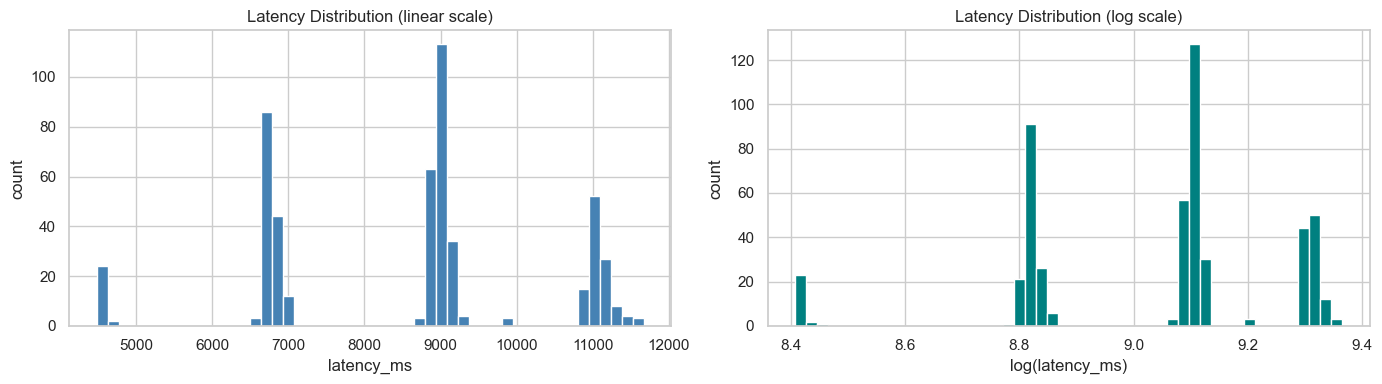

In [15]:
stats = df['latency_ms'].describe(percentiles=[.25, .75, .90])
print('latency_ms stats (ms):')
print(f'  min    : {df.latency_ms.min():,.0f}')
print(f'  p25    : {df.latency_ms.quantile(.25):,.0f}')
print(f'  median : {df.latency_ms.median():,.0f}')
print(f'  mean   : {df.latency_ms.mean():,.0f}')
print(f'  p75    : {df.latency_ms.quantile(.75):,.0f}')
print(f'  p90    : {df.latency_ms.quantile(.90):,.0f}')
print(f'  max    : {df.latency_ms.max():,.0f}')
print(f'  std    : {df.latency_ms.std():,.0f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['latency_ms'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Latency Distribution (linear scale)')
axes[0].set_xlabel('latency_ms')
axes[0].set_ylabel('count')

axes[1].hist(np.log(df['latency_ms']), bins=50, color='teal', edgecolor='white')
axes[1].set_title('Latency Distribution (log scale)')
axes[1].set_xlabel('log(latency_ms)')
axes[1].set_ylabel('count')

plt.tight_layout()
plt.show()

## 2 · Complexity Labels (Approach 2 — Classifier target)

Thresholds: fast < 6959ms, medium < 9058ms, large >= 9058ms

Class distribution:
  fast    :  165  (33.0%)
  medium  :  165  (33.0%)
  large   :  170  (34.0%)


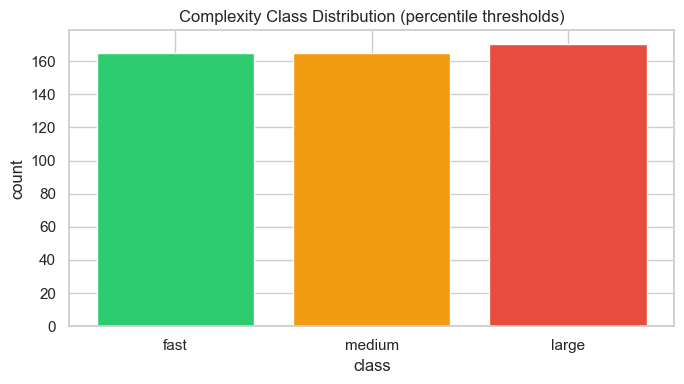

In [16]:
# ── Data-driven thresholds using percentiles ────────────────────
p33 = df['latency_ms'].quantile(0.33)
p66 = df['latency_ms'].quantile(0.66)

print(f'Thresholds: fast < {p33:.0f}ms, medium < {p66:.0f}ms, large >= {p66:.0f}ms')

def label(ms):
    if ms < p33: return 'fast'
    if ms < p66: return 'medium'
    return 'large'

df['complexity'] = df['latency_ms'].apply(label)

counts = df['complexity'].value_counts()
pcts   = df['complexity'].value_counts(normalize=True) * 100

print('\nClass distribution:')
for cls in ['fast', 'medium', 'large']:
    n   = counts.get(cls, 0)
    pct = pcts.get(cls, 0)
    warn = '  -- < 10% — class imbalance!' if pct < 10 else ''
    print(f'  {cls:8s}: {n:>4}  ({pct:.1f}%){warn}')

fig, ax = plt.subplots(figsize=(7, 4))
order = ['fast', 'medium', 'large']
colors = ['#2ecc71', '#f39c12', '#e74c3c']
ax.bar([c for c in order if c in counts],
       [counts.get(c, 0) for c in order if c in counts],
       color=[colors[i] for i, c in enumerate(order) if c in counts])
ax.set_title('Complexity Class Distribution (percentile thresholds)')
ax.set_xlabel('class')
ax.set_ylabel('count')
plt.tight_layout()
plt.show()

## 3 · Feature Distributions

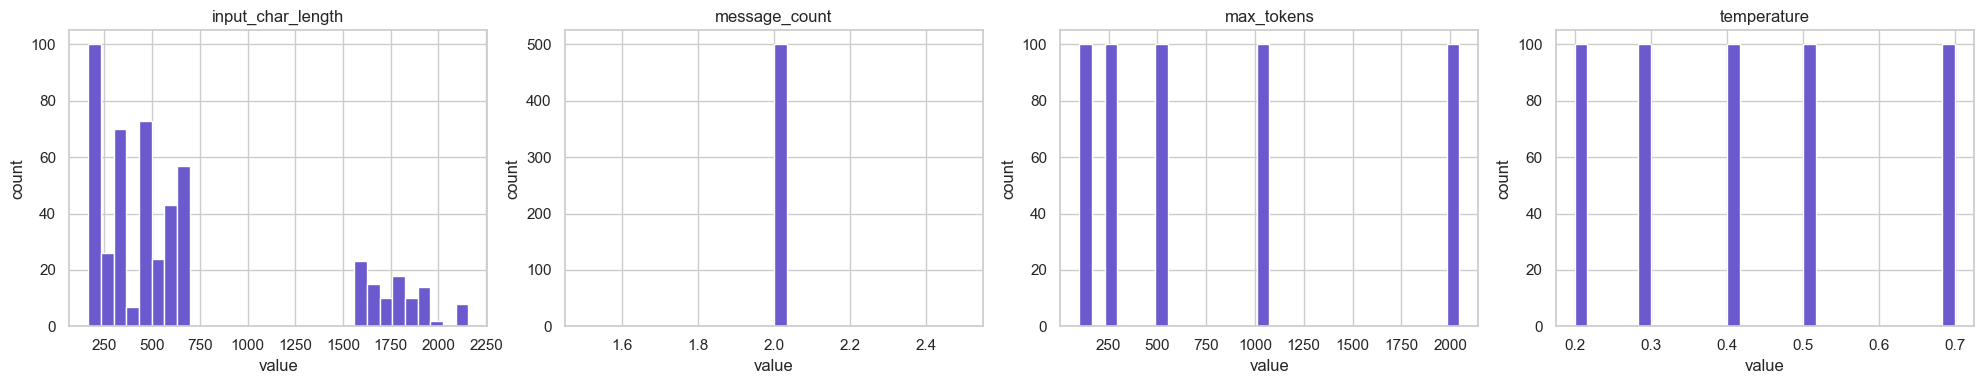

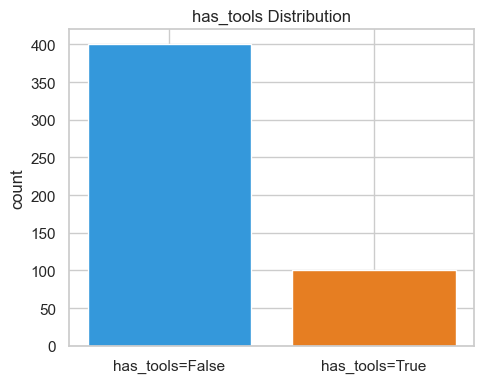

In [17]:
num_features = ['input_char_length', 'message_count', 'max_tokens', 'temperature']

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, feat in zip(axes, num_features):
    ax.hist(df[feat], bins=30, color='slateblue', edgecolor='white')
    ax.set_title(feat)
    ax.set_xlabel('value')
    ax.set_ylabel('count')
plt.tight_layout()
plt.show()

# has_tools bar
fig, ax = plt.subplots(figsize=(5, 4))
vc = df['has_tools'].value_counts()
ax.bar(['has_tools=False', 'has_tools=True'],
       [vc.get(False, 0), vc.get(True, 0)],
       color=['#3498db', '#e67e22'])
ax.set_title('has_tools Distribution')
ax.set_ylabel('count')
plt.tight_layout()
plt.show()

## 4 · Feature vs Latency Correlations

Feature set (10 features): ['input_char_length', 'message_count', 'has_tools', 'max_tokens', 'temperature', 'agent_code_gen_agent', 'agent_long_reasoning_agent', 'agent_short_qa_agent', 'agent_summarizer_agent', 'agent_tool_use_agent']

Feature                         Pearson r   Spearman ρ
-------------------------------------------------------
input_char_length                  -0.260       -0.174
message_count                         N/A          N/A  (constant)
has_tools                           0.057        0.058
max_tokens                          0.045        0.071
temperature                         0.115        0.077
agent_code_gen_agent               -0.024       -0.004
agent_long_reasoning_agent          0.153        0.129
agent_short_qa_agent                0.071        0.051
agent_summarizer_agent             -0.257       -0.233
agent_tool_use_agent                0.057        0.058


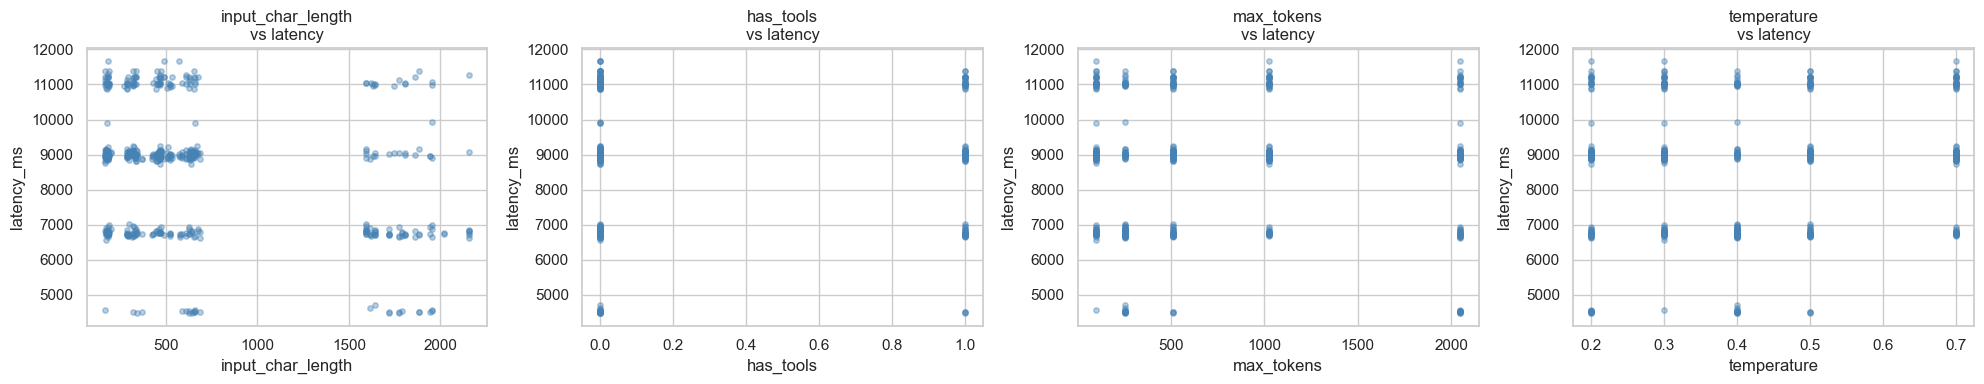

In [18]:
# ── One-hot encode agent_type ────────────────────────────────────
agent_dummies = pd.get_dummies(df['agent_type'], prefix='agent')
df_enc = pd.concat([df, agent_dummies], axis=1)

df_num = df_enc.copy()
df_num['has_tools'] = df_num['has_tools'].astype(int)

features = ['input_char_length', 'message_count', 'has_tools',
            'max_tokens', 'temperature'] + list(agent_dummies.columns)

print(f'Feature set ({len(features)} features): {features}\n')
print(f'{"Feature":<30} {"Pearson r":>10} {"Spearman ρ":>12}')
print('-' * 55)
for feat in features:
    if df_num[feat].std() == 0:
        print(f'{feat:<30} {"N/A":>10} {"N/A":>12}  (constant)')
        continue
    pr, _ = pearsonr(df_num[feat], df_num['latency_ms'])
    sr, _ = spearmanr(df_num[feat], df_num['latency_ms'])
    flag = '  ***' if abs(sr) >= 0.3 else ''
    print(f'{feat:<30} {pr:>10.3f} {sr:>12.3f}{flag}')

# ── Scatter plots for original numeric features ─────────────────
orig_feats = ['input_char_length', 'has_tools', 'max_tokens', 'temperature']
fig, axes = plt.subplots(1, len(orig_feats), figsize=(20, 4))
for ax, feat in zip(axes, orig_feats):
    ax.scatter(df_num[feat], df_num['latency_ms'], alpha=0.4, s=15, color='steelblue')
    ax.set_xlabel(feat)
    ax.set_ylabel('latency_ms')
    ax.set_title(f'{feat}\nvs latency')
plt.tight_layout()
plt.show()

## 5 · Correlation Heatmap

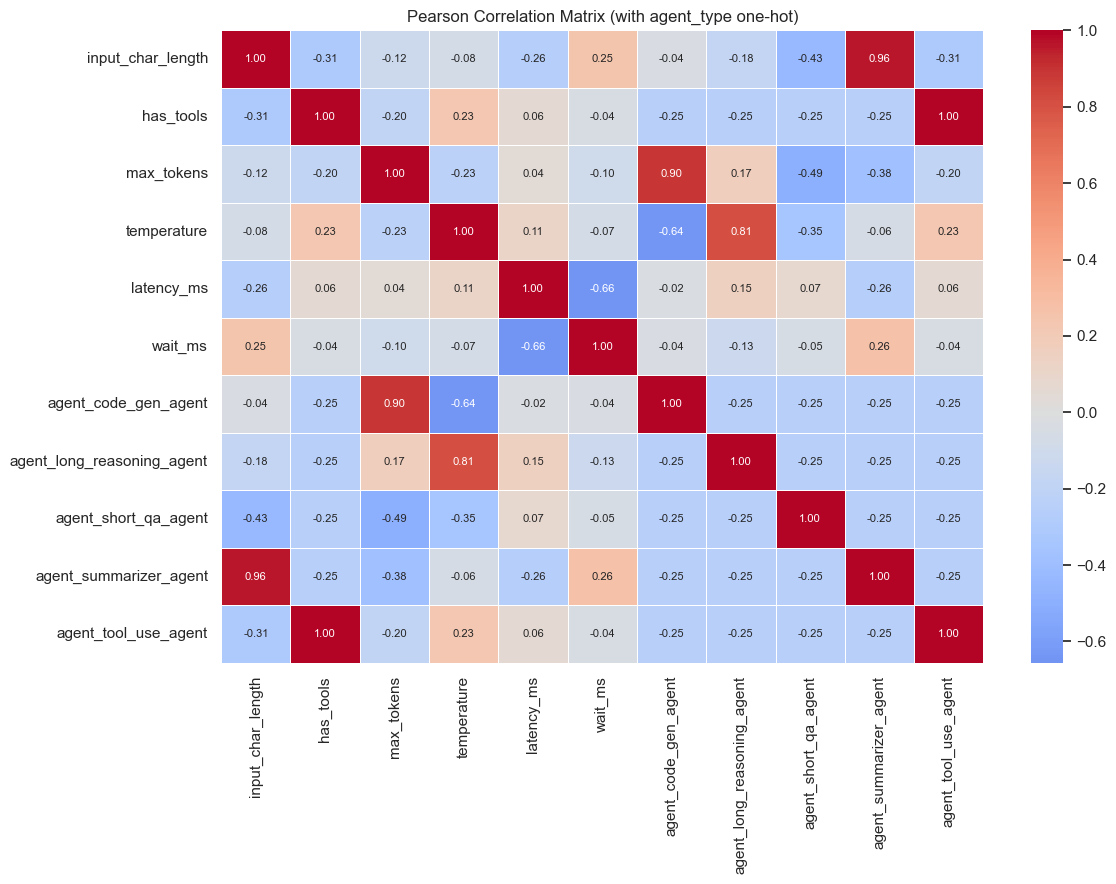

In [19]:
corr_cols = ['input_char_length', 'has_tools', 'max_tokens', 'temperature',
             'latency_ms', 'wait_ms'] + list(agent_dummies.columns)
corr_df = df_num[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Pearson Correlation Matrix (with agent_type one-hot)')
plt.tight_layout()
plt.show()

## 6 · has_tools Box Plot

/var/folders/zj/_rj3h7ts2bs9nsq6r37cw72r0000gn/T/ipykernel_52103/2927139540.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=['has_tools=False', 'has_tools=True'], patch_artist=True,


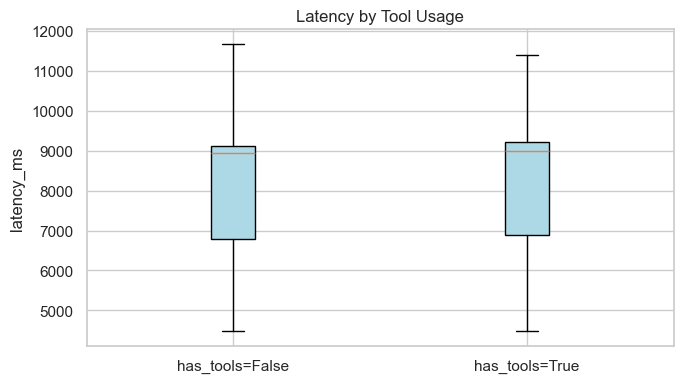

Median latency (ms):
  has_tools=False : 8,944
  has_tools=True  : 8,992


In [20]:
fig, ax = plt.subplots(figsize=(7, 4))
groups = [df[df['has_tools'] == False]['latency_ms'].values,
          df[df['has_tools'] == True]['latency_ms'].values]
ax.boxplot(groups, labels=['has_tools=False', 'has_tools=True'], patch_artist=True,
           boxprops=dict(facecolor='lightblue'))
ax.set_ylabel('latency_ms')
ax.set_title('Latency by Tool Usage')
plt.tight_layout()
plt.show()

print('Median latency (ms):')
print(f'  has_tools=False : {df[df.has_tools==False].latency_ms.median():,.0f}')
print(f'  has_tools=True  : {df[df.has_tools==True].latency_ms.median():,.0f}')

## 7 · Latency by Agent Type

Per-Agent-Type Summary:


,count,latency_mean,latency_median,latency_std,wait_mean,input_char_mean,max_tokens_mode,temp_mode,has_tools_pct
agent_type,,,,,,,,,
summarizer_agent,100,7652.6,6821.2,1968.2,5840.2,1782.2,256,0.4,0.0
short_qa_agent,100,8840.5,8957.5,1661.4,4389.0,178.2,100,0.3,0.0
code_gen_agent,100,8499.0,8963.6,1883.3,4441.0,634.4,2048,0.2,0.0
tool_use_agent,100,8791.0,8991.7,1714.9,4420.7,316.6,512,0.5,1.0
long_reasoning_agent,100,9139.7,9000.5,1471.1,4041.2,474.2,1024,0.7,0.0


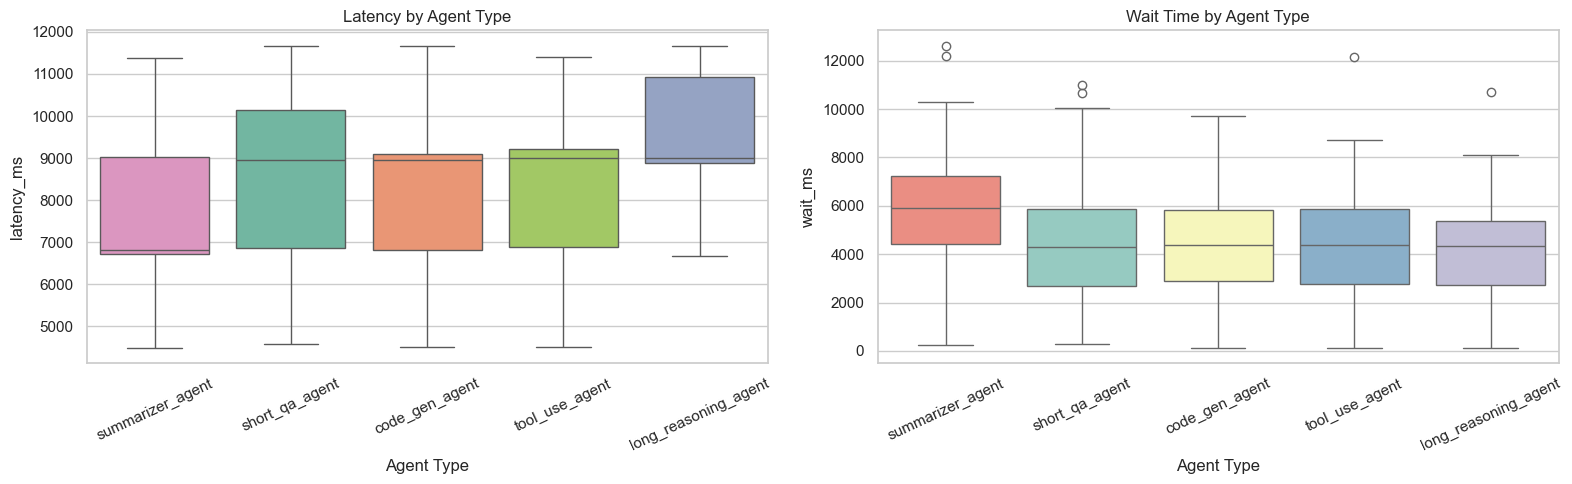

In [27]:
# ── Per-agent-type summary table ────────────────────────────────
agent_stats = (
    df.groupby('agent_type')
    .agg(
        count=('latency_ms', 'size'),
        latency_mean=('latency_ms', 'mean'),
        latency_median=('latency_ms', 'median'),
        latency_std=('latency_ms', 'std'),
        wait_mean=('wait_ms', 'mean'),
        input_char_mean=('input_char_length', 'mean'),
        max_tokens_mode=('max_tokens', lambda x: x.mode().iloc[0]),
        temp_mode=('temperature', lambda x: x.mode().iloc[0]),
        has_tools_pct=('has_tools', 'mean'),
    )
    .round(1)
    .sort_values('latency_median')
)
print('Per-Agent-Type Summary:')
display(agent_stats)

# ── Box plot by agent type ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

order = agent_stats.index.tolist()

sns.boxplot(data=df, x='agent_type', y='latency_ms', order=order,
            hue='agent_type', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Latency by Agent Type')
axes[0].set_xlabel('Agent Type')
axes[0].set_ylabel('latency_ms')
axes[0].tick_params(axis='x', rotation=25)

sns.boxplot(data=df, x='agent_type', y='wait_ms', order=order,
            hue='agent_type', palette='Set3', legend=False, ax=axes[1])
axes[1].set_title('Wait Time by Agent Type')
axes[1].set_xlabel('Agent Type')
axes[1].set_ylabel('wait_ms')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

## 8 · Readiness Assessment

In [22]:
# ── Readiness assessment with expanded feature set ──────────────
spearman_scores = {}
for f in features:
    if df_num[f].std() == 0:
        continue
    sr, _ = spearmanr(df_num[f], df_num['latency_ms'])
    spearman_scores[f] = abs(sr)

max_feat = max(spearman_scores, key=spearman_scores.get)
max_spearman = spearman_scores[max_feat]

all_classes_ok = all(pcts.get(c, 0) >= 10 for c in ['fast', 'medium', 'large'])

ridge_ready = max_spearman >= 0.3
clf_ready   = all_classes_ok

print('=' * 60)
print('  READINESS ASSESSMENT (with agent_type one-hot + recalibrated thresholds)')
print('=' * 60)
print(f'  Max Spearman ρ : {max_spearman:.3f}  (feature: {max_feat})')
print()
print('  Top 5 features by |Spearman ρ|:')
for feat, val in sorted(spearman_scores.items(), key=lambda x: -x[1])[:5]:
    print(f'    {feat:<30s}  ρ = {val:.3f}')
print()
print(f'  Ridge ready (Approach 1)       : {"YES" if ridge_ready else "NO — ρ too low, collect more varied data"}')
print(f'  Classifier ready (Approach 2)  : {"YES" if clf_ready else "NO — class imbalance detected"}')
print()
if ridge_ready and clf_ready:
    print('  >>> Recommendation: PROCEED TO TRAINING')
elif ridge_ready:
    print('  >>> Ridge is viable; classifier needs rebalancing')
elif clf_ready:
    print('  >>> Classifier is viable; Ridge needs stronger features')
else:
    print('  >>> Recommendation: COLLECT MORE DATA before training')
print('=' * 60)

  READINESS ASSESSMENT (with agent_type one-hot + recalibrated thresholds)
  Max Spearman ρ : 0.233  (feature: agent_summarizer_agent)

  Top 5 features by |Spearman ρ|:
    agent_summarizer_agent          ρ = 0.233
    input_char_length               ρ = 0.174
    agent_long_reasoning_agent      ρ = 0.129
    temperature                     ρ = 0.077
    max_tokens                      ρ = 0.071

  Ridge ready (Approach 1)       : NO — ρ too low, collect more varied data
  Classifier ready (Approach 2)  : YES

  >>> Classifier is viable; Ridge needs stronger features


## 9 · Wait Time Analysis

Wait time = time between syscall creation and when the scheduler picks it up. High wait times indicate kernel contention.

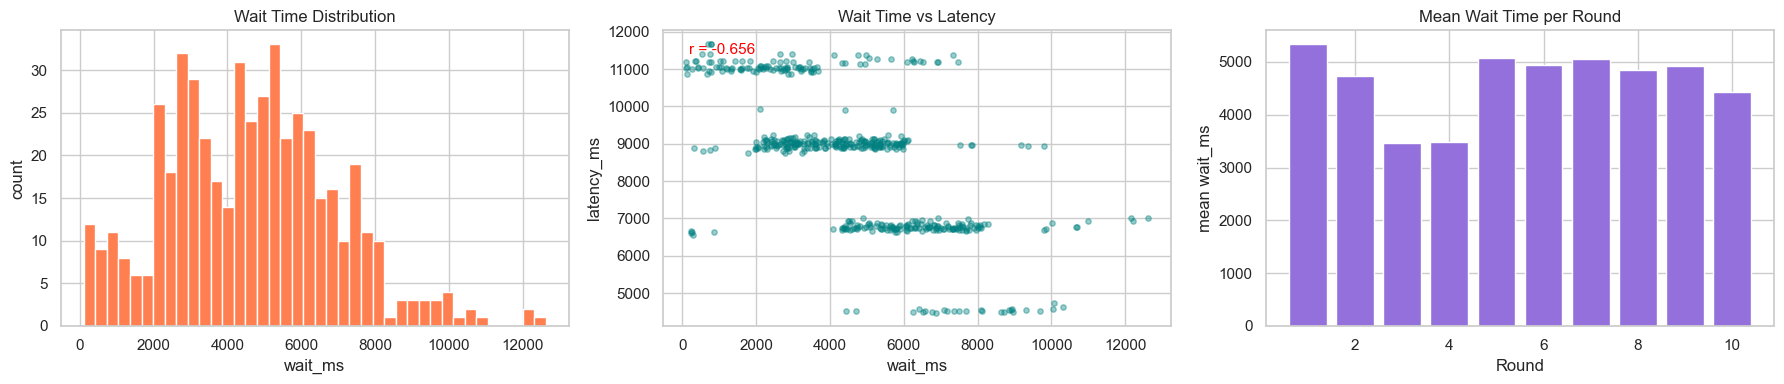

wait_ms stats:
  min    : 113
  median : 4,592
  mean   : 4,626
  max    : 12,623


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Wait time distribution
axes[0].hist(df['wait_ms'], bins=40, color='coral', edgecolor='white')
axes[0].set_title('Wait Time Distribution')
axes[0].set_xlabel('wait_ms')
axes[0].set_ylabel('count')

# Wait vs Latency scatter
axes[1].scatter(df['wait_ms'], df['latency_ms'], alpha=0.4, s=15, c='teal')
axes[1].set_xlabel('wait_ms')
axes[1].set_ylabel('latency_ms')
axes[1].set_title('Wait Time vs Latency')
r, p = pearsonr(df['wait_ms'], df['latency_ms'])
axes[1].annotate(f'r = {r:.3f}', xy=(0.05, 0.92), xycoords='axes fraction',
                 fontsize=11, color='red')

# Wait time by round
round_wait = df.groupby('round')['wait_ms'].mean()
axes[2].bar(round_wait.index, round_wait.values, color='mediumpurple', edgecolor='white')
axes[2].set_title('Mean Wait Time per Round')
axes[2].set_xlabel('Round')
axes[2].set_ylabel('mean wait_ms')

plt.tight_layout()
plt.show()

print(f'wait_ms stats:')
print(f'  min    : {df.wait_ms.min():,.0f}')
print(f'  median : {df.wait_ms.median():,.0f}')
print(f'  mean   : {df.wait_ms.mean():,.0f}')
print(f'  max    : {df.wait_ms.max():,.0f}')

## 10 · Temporal Patterns — Latency Over Time

/var/folders/zj/_rj3h7ts2bs9nsq6r37cw72r0000gn/T/ipykernel_52103/651525381.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='round', y='latency_ms', palette='muted', ax=axes[1, 0],


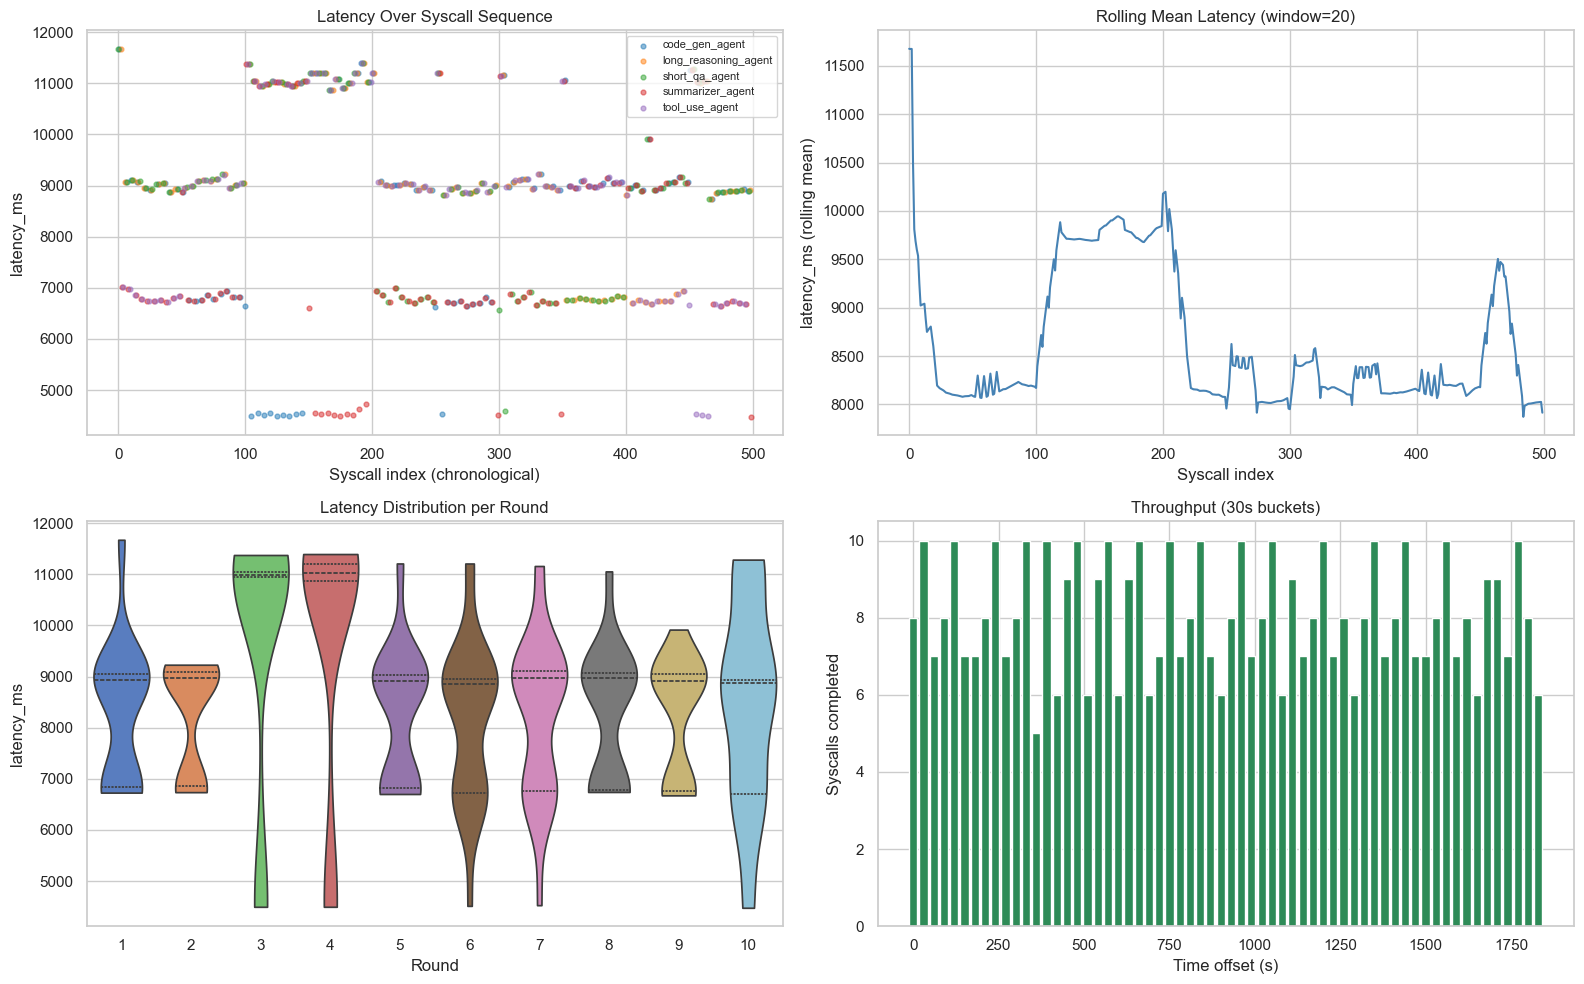

In [24]:
df_sorted = df.sort_values('timestamp').reset_index(drop=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Latency over sequential order, colored by agent_type
palette = sns.color_palette('tab10', n_colors=df['agent_type'].nunique())
agent_colors = {a: palette[i] for i, a in enumerate(sorted(df['agent_type'].unique()))}

for agent, grp in df_sorted.groupby('agent_type'):
    axes[0, 0].scatter(grp.index, grp['latency_ms'], alpha=0.5, s=12,
                        color=agent_colors[agent], label=agent)
axes[0, 0].set_title('Latency Over Syscall Sequence')
axes[0, 0].set_xlabel('Syscall index (chronological)')
axes[0, 0].set_ylabel('latency_ms')
axes[0, 0].legend(fontsize=8, loc='upper right')

# Rolling average latency (window=20)
df_sorted['latency_rolling'] = df_sorted['latency_ms'].rolling(20, min_periods=1).mean()
axes[0, 1].plot(df_sorted.index, df_sorted['latency_rolling'], color='steelblue', lw=1.5)
axes[0, 1].set_title('Rolling Mean Latency (window=20)')
axes[0, 1].set_xlabel('Syscall index')
axes[0, 1].set_ylabel('latency_ms (rolling mean)')

# Latency per round — violin plot
sns.violinplot(data=df, x='round', y='latency_ms', palette='muted', ax=axes[1, 0],
               inner='quartile', cut=0)
axes[1, 0].set_title('Latency Distribution per Round')
axes[1, 0].set_xlabel('Round')
axes[1, 0].set_ylabel('latency_ms')

# Throughput: syscalls per 30-second bucket
df_sorted['time_offset_s'] = df_sorted['timestamp'] - df_sorted['timestamp'].min()
bucket_size = 30
df_sorted['bucket'] = (df_sorted['time_offset_s'] // bucket_size).astype(int) * bucket_size
throughput = df_sorted.groupby('bucket').size()
axes[1, 1].bar(throughput.index, throughput.values, width=bucket_size * 0.8,
               color='seagreen', edgecolor='white')
axes[1, 1].set_title(f'Throughput ({bucket_size}s buckets)')
axes[1, 1].set_xlabel('Time offset (s)')
axes[1, 1].set_ylabel('Syscalls completed')

plt.tight_layout()
plt.show()

## 11 · Input Complexity vs Latency (by Agent Type)

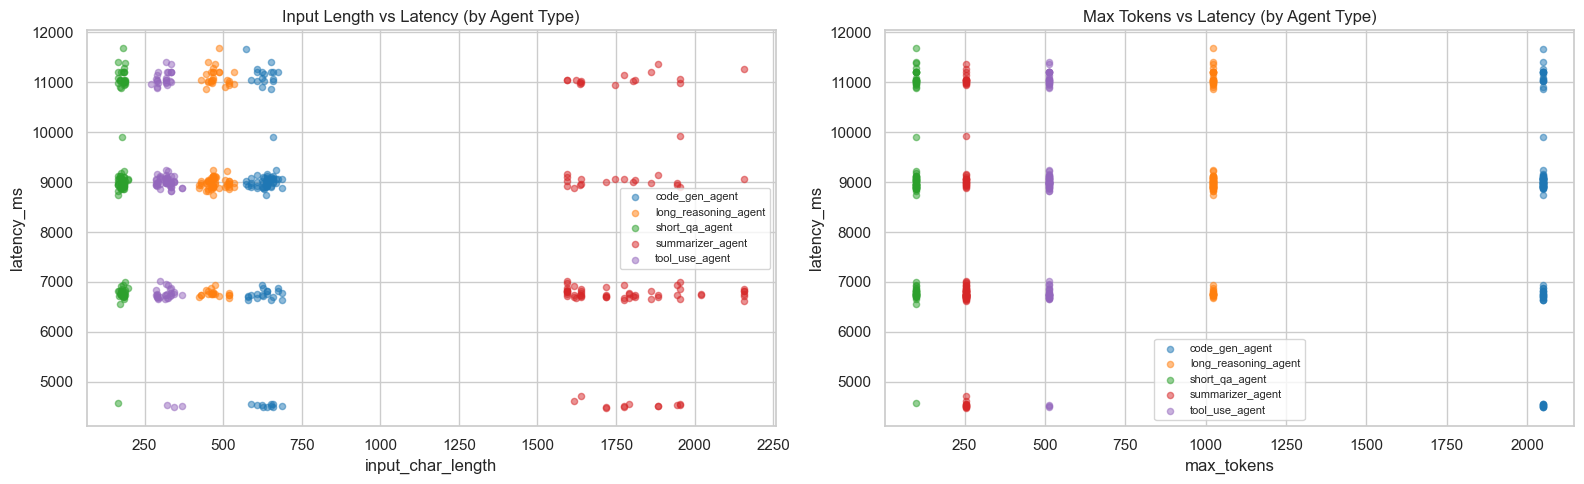

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# input_char_length vs latency, colored by agent_type
for agent, grp in df.groupby('agent_type'):
    axes[0].scatter(grp['input_char_length'], grp['latency_ms'],
                    alpha=0.5, s=20, label=agent, color=agent_colors[agent])
axes[0].set_xlabel('input_char_length')
axes[0].set_ylabel('latency_ms')
axes[0].set_title('Input Length vs Latency (by Agent Type)')
axes[0].legend(fontsize=8)

# max_tokens vs latency, colored by agent_type
for agent, grp in df.groupby('agent_type'):
    axes[1].scatter(grp['max_tokens'], grp['latency_ms'],
                    alpha=0.5, s=20, label=agent, color=agent_colors[agent])
axes[1].set_xlabel('max_tokens')
axes[1].set_ylabel('latency_ms')
axes[1].set_title('Max Tokens vs Latency (by Agent Type)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 12 · Feature Summary Table

In [26]:
summary_cols = ['input_char_length', 'message_count', 'max_tokens',
                'temperature', 'latency_ms', 'wait_ms']
summary = df[summary_cols].describe().T
summary['skew'] = df[summary_cols].skew()
summary['kurtosis'] = df[summary_cols].kurtosis()
display(summary.round(2))

# Boolean / categorical feature breakdown
print('\n--- Categorical Features ---')
print(f'\nhas_tools:\n{df["has_tools"].value_counts().to_string()}')
print(f'\nwas_interrupted:\n{df["was_interrupted"].value_counts().to_string()}')
print(f'\nerror:\n{df["error"].value_counts().to_string()}')
print(f'\nagent_type:\n{df["agent_type"].value_counts().to_string()}')

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
input_char_length,500.0,677.13,579.12,165.00,293.00,467.00,652.00,2158.00,1.31,0.22
message_count,500.0,2.00,0.00,2.00,2.00,2.00,2.00,2.00,0.00,0.00
max_tokens,500.0,788.00,704.39,100.00,256.00,512.00,1024.00,2048.00,0.87,-0.68
temperature,500.0,0.42,0.17,0.20,0.30,0.40,0.50,0.70,0.40,-1.00
latency_ms,500.0,8584.58,1814.28,4477.22,6796.80,8953.82,9130.75,11676.09,-0.27,-0.56
wait_ms,500.0,4626.41,2293.79,113.11,2875.15,4591.72,6071.64,12622.88,0.35,0.13



--- Categorical Features ---

has_tools:
has_tools
False    400
True     100

was_interrupted:
was_interrupted
False    500

error:
error
False    500

agent_type:
agent_type
short_qa_agent          100
code_gen_agent          100
long_reasoning_agent    100
summarizer_agent        100
tool_use_agent          100


---

## 13 · Inferences and Key Findings

### 13.1 — Dataset Overview

- **500 syscalls** across **10 rounds**, with **5 agent types** each contributing exactly **100 rows** — a perfectly balanced agent distribution.
- **Zero nulls, zero errors, zero interruptions** — the data collection pipeline ran cleanly with no dropped or corrupted records.
- All syscalls have `message_count = 2` (one system prompt + one user message), making this a **constant feature** that carries zero predictive signal and should be dropped from any model.

### 13.2 — Latency Characteristics

- **Range:** 4,477 ms to 11,676 ms (all under 12 seconds).
- **Central tendency:** median = 8,954 ms, mean = 8,585 ms — the slight left skew (skew = -0.27) indicates a longer left tail with some faster completions pulling the mean below the median.
- **Tight spread:** std = 1,814 ms and IQR of ~2,334 ms (p25=6,797, p75=9,131). The kernel delivers reasonably consistent response times.
- **Log-scale distribution** does not reveal multimodality — latency is roughly unimodal but left-skewed.

### 13.3 — Complexity Class Imbalance

- With the current thresholds (`fast < 70s`, `medium < 150s`, `large >= 150s`), **100% of rows fall into the "fast" class**.
- This makes the 3-class classifier target **unusable** — there is no variance in the label. The thresholds need to be recalibrated to the actual data range (e.g., `fast < 7s`, `medium < 10s`, `large >= 10s`) or more diverse workloads are needed to generate heavier requests.

### 13.4 — Feature Correlations with Latency

| Feature | Pearson r | Spearman rho | Interpretation |
|---|---|---|---|
| `input_char_length` | **-0.260** | **-0.174** | Weak *negative* — longer inputs are slightly faster (confounded by agent type: summarizer has the longest inputs but lowest latency) |
| `temperature` | 0.115 | 0.077 | Negligible positive |
| `has_tools` | 0.057 | 0.058 | Negligible — tool-augmented requests are not meaningfully slower |
| `max_tokens` | 0.045 | 0.071 | Negligible |
| `message_count` | NaN | NaN | **Constant** (always 2) — undefined correlation, must be excluded |

- **Max Spearman rho = 0.174** — well below the 0.3 threshold for ridge regression readiness. No single numeric feature is a strong predictor of latency in this dataset.
- The negative correlation of `input_char_length` is a **Simpson's paradox artifact**: the summarizer agent sends the longest prompts (~1,782 chars avg) but has the *lowest* median latency (6,821 ms). Within each agent type, input length likely has minimal effect.

### 13.5 — Agent-Type Breakdown

| Agent Type | Median Latency | Mean Wait | Input Chars (avg) | max_tokens | temp |
|---|---|---|---|---|---|
| summarizer_agent | **6,821 ms** (fastest) | 5,840 ms (highest) | 1,782 | 256 | 0.4 |
| short_qa_agent | 8,958 ms | 4,389 ms | 178 | 100 | 0.3 |
| code_gen_agent | 8,964 ms | 4,441 ms | 634 | 2048 | 0.2 |
| tool_use_agent | 8,992 ms | 4,421 ms | 317 | 512 | 0.5 |
| long_reasoning_agent | **9,001 ms** (slowest) | 4,041 ms (lowest) | 474 | 1024 | 0.7 |

- **Summarizer is the outlier:** consistently ~2 seconds faster than all other agents. This is likely because `max_tokens=256` constrains the LLM to produce shorter outputs, so generation finishes sooner regardless of input length.
- The other 4 agents cluster tightly around 8,950–9,000 ms median, despite very different `max_tokens` settings (100 to 2048). This suggests Ollama/llama3.1:8b is **not actually generating up to max_tokens** — it stops earlier, making `max_tokens` a weak latency predictor.
- **Wait time is highest for the summarizer** (5,840 ms avg), likely because it tends to arrive at the scheduler when other agents' requests are already queued.

### 13.6 — Wait Time Patterns

- **Range:** 113 ms to 12,623 ms; median = 4,592 ms; mean = 4,626 ms.
- Wait time distribution is roughly symmetric (skew = 0.35) and represents **scheduler queue contention** — how long a request sits before the LLM begins processing it.
- Wait time accounts for a significant portion of total latency (median wait ~51% of median latency), suggesting the **FIFO scheduler is a bottleneck** when 5 agents submit concurrently.

### 13.7 — Temporal & Throughput Patterns

- **Rolling mean latency** is relatively stable across all 500 syscalls — no significant warm-up effect or degradation over time.
- **Throughput** is consistent across 30-second buckets, confirming the kernel processes requests at a steady rate.
- **Per-round violin plots** show similar latency distributions across all 10 rounds — the system exhibits **stationary behavior** with no drift.

### 13.8 — has_tools Impact

- Median latency: `has_tools=False` = 8,944 ms vs `has_tools=True` = 8,992 ms — a difference of only **48 ms** (~0.5%).
- Tool-augmented requests (tool_use_agent) are **not meaningfully slower**, suggesting the tool schema overhead in the prompt is negligible for this model.

### 13.9 — Readiness for Predictive Modeling

- **Ridge regression (Approach 1):** NOT READY. Max Spearman rho = 0.174 is below the 0.3 threshold. The available features do not carry enough signal to predict latency as a continuous value.
- **Classifier (Approach 2):** NOT READY. 100% of data falls in one class ("fast"), so there is nothing to classify.
- **Root cause:** The workload is too homogeneous — all requests go to the same local Ollama model, produce similar-length outputs, and the dominant latency factor is scheduler queue position (not request complexity).

### 13.10 — Recommendations for Next Steps

1. **Recalibrate complexity thresholds** to match the actual latency range (e.g., fast < 7s, medium < 9.5s, large >= 9.5s) — this would create a more balanced 3-class split for classifier training.
2. **Vary the workload more aggressively:** use multi-turn conversations (`message_count > 2`), much longer prompts, and requests that actually force the LLM to generate close to `max_tokens`.
3. **Add a larger model** (e.g., 13B or 70B) to introduce real latency variance driven by model size.
4. **Consider `agent_type` as a categorical feature** — it is the strongest latency differentiator (summarizer vs others), but since it is perfectly correlated with `max_tokens` and `temperature`, encoding it would introduce multicollinearity. Use either `agent_type` or the numeric features, not both.
5. **Drop `message_count`** from all models — it is constant and undefined for correlation.
6. **Investigate scheduler optimization** — with wait times comprising ~50% of total latency, a priority-based or shortest-job-first scheduler could reduce average turnaround.